In [1]:
import os, json, joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from collections import defaultdict
from typing import Dict, List,Tuple, Any, Optional
import math
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc,
)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import preprocess as pp
import optuna
import DTC_Config
print("TF version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TF version: 2.10.0
Num GPUs Available: 1


C:\Users\yonat\anaconda3\envs\tf210gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_vehicle_csv(path: str, cfg: DTC_Config.Config) -> pd.DataFrame:
    df = pd.read_csv(path)
    current_target = "DTC"
    time_col = df.iloc[:, 0]
    ts = pp.parse_timestamp(time_col, cfg.timestamp_format_try)

    df = df.drop(df.columns[0], axis=1).copy()
    df.insert(0, "timestamp", ts)
    if current_target not in df.columns:
        raise ValueError(f"Missing target column '{current_target}' in {path}")
    df[cfg.target] = df[current_target].apply(lambda x: 0 if str(x).strip() == "0" else 1).astype(int)

    df["vehicle_id"] = os.path.splitext(os.path.basename(path))[0].replace("_user", "")
    return df

In [3]:
def load_all(cfg: DTC_Config.Config) -> pd.DataFrame:
    frames: List[pd.DataFrame] = []
    for f in cfg.files:
        p = os.path.join(cfg.data_dir, f)
        
        if not os.path.exists(p):
            print(f"  File not found, skipping.")
            continue
        frames.append(load_vehicle_csv(p, cfg))
    if not frames:
        raise FileNotFoundError("No dataset files found. Check cfg.data_dir and cfg.files.")

    df = pd.concat(frames, ignore_index=True)
    df = df.dropna(subset=["timestamp"]).sort_values(["vehicle_id", "timestamp"]).reset_index(drop=True)
    df = df.drop(columns=["DTC"], errors="ignore")
    return df

In [4]:
def split_train_val_test_per_vehicle(
    df: pd.DataFrame, test_ratio_last: float, val_ratio_last: float
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    trains, vals, tests = [], [], []
    for g in df.groupby("vehicle_id", sort=False):
        g = g[1].sort_values("timestamp")
        n = len(g)
        n_test = max(1, int(n * test_ratio_last))
        test = g.iloc[-n_test:]
        remain = g.iloc[: n - n_test]
        n_val = max(1, int(len(remain) * val_ratio_last))
        val = remain.iloc[-n_val:]
        train = remain.iloc[: len(remain) - n_val]
        if len(train) < 2:
            continue
        trains.append(train)
        vals.append(val)
        tests.append(test)
    return pd.concat(trains), pd.concat(vals), pd.concat(tests)

In [5]:
def compute_class_weights(y: np.ndarray) -> Dict[int, float]:
    pos = y.sum()
    neg = len(y) - pos
    if pos == 0 or neg == 0:
        return {0: 1.0, 1: 1.0}
    w_pos = neg / max(1.0, pos)
    w_neg = 1.0
    return {0: w_neg, 1: w_pos}

In [6]:
def make_windows(
    df: pd.DataFrame,
    features: List[str],
    target: str,
    seq_len: int,
    horizon: int,
    stride: int,
) -> Tuple[np.ndarray, np.ndarray]:
    Xs, ys, gids, y_ts = [], [], [], []

    for gid, g in df.groupby("vehicle_id", sort=True, dropna=False):
        g = g.sort_values("timestamp").reset_index(drop=True)

        feat = g[features].to_numpy(dtype=np.float32, copy=False)  
        tgt  = g[target].to_numpy()                              
        ts   = g["timestamp"].to_numpy()                          

        end = len(g) - horizon
        n_windows = end - seq_len + 1
        if n_windows <= 0:
            raise ValueError(f"Not enough data for vehicle {gid} to create a single window.")

        for start in range(0, n_windows, stride):
            stop = start + seq_len
            Xs.append(feat[start:stop])                    
            ys.append(int(tgt[stop - 1 + horizon]))         
            gids.append(gid)
            y_ts.append(ts[stop - 1 + horizon])           

    if not Xs:
        F = len(features)
        return (np.empty((0, seq_len, F), dtype=np.float32),
                np.empty((0,), dtype=np.int32),
                np.empty((0,), dtype=object),
                np.empty((0,), dtype="datetime64[ns]"))

    X = np.stack(Xs).astype(np.float32, copy=False)
    y = np.asarray(ys,  dtype=np.int32)
    gids = np.asarray(gids, dtype=object)
    y_ts = np.asarray(y_ts)
    return X, y

In [7]:
def build_model(input_len, n_features, cfg):
    inputs = layers.Input(shape=(input_len, n_features))
    if cfg.bidirectional:
        x = layers.Bidirectional(layers.LSTM(cfg.hidden, dropout=cfg.dropout, return_sequences=False))(inputs)
    else:
        x = layers.LSTM(cfg.hidden, dropout=cfg.dropout, return_sequences=False)(inputs)
    x = layers.Dense(cfg.hidden // 2, activation="relu")(x)
    x = layers.Dropout(cfg.dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                 tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.Precision(name="precision")]
    )
    return model

In [8]:
def make_tf_dataset(
    X: np.ndarray,
    y: np.ndarray,
    batch_size: int,
    *,
    shuffle: bool = False,
    seed: int = 42,
):
    if len(X) != len(y): 
        raise ValueError("X and y length mismatch")
    if len(X) == 0:
        raise ValueError("empty dataset")

    ds = tf.data.Dataset.from_tensor_slices(
        (tf.convert_to_tensor(X, tf.float32), tf.convert_to_tensor(y, tf.float32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 10_000), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size, drop_remainder=bool(shuffle))
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [9]:
def _safe_get(h, k):
    return h[k] if k in h else None

def plot_training_curves(history):
    h = history.history  
    
    def f1(p, r):
        return [ (2*pp*rr)/(pp+rr+1e-12) if (pp is not None and rr is not None and (pp+rr)>0) else math.nan
                 for pp, rr in zip(p or [], r or []) ]

    train_prec,  val_prec  = _safe_get(h, "precision"),   _safe_get(h, "val_precision")
    train_rec,   val_rec   = _safe_get(h, "recall"),      _safe_get(h, "val_recall")
    train_f1 = f1(train_prec, train_rec) if train_prec and train_rec else None
    val_f1   = f1(val_prec, val_rec)     if val_prec and val_rec     else None

    charts = [
        ("loss",        "val_loss",        "Loss"),
        ("pr_auc",      "val_pr_auc",      "PR AUC"),
        ("roc_auc",     "val_roc_auc",     "ROC AUC"),
        ("precision",   "val_precision",   "Precision"),
        ("recall",      "val_recall",      "Recall"),
    ]

    for train_k, val_k, title in charts:
        if train_k in h or val_k in h:
            plt.figure()
            if train_k in h: plt.plot(h[train_k], label=f"train_{train_k}")
            if val_k   in h: plt.plot(h[val_k],   label=f"val_{train_k}")
            plt.title(title); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)
            plt.show()

    if train_f1 or val_f1:
        plt.figure()
        if train_f1: plt.plot(train_f1, label="train_f1")
        if val_f1:   plt.plot(val_f1,   label="val_f1")
        plt.title("F1 (derived from precision/recall)"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)
        plt.show()

In [10]:
def plot_test_curves(
    y_true,
    y_prob,
    threshold=0.5,
    title_suffix=" (test)",
    cfg=None,
    *,
    normalize_cm: bool = True,
    dpi: int = 120,
):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    if y_true.size == 0 or y_prob.size == 0:
        raise ValueError("plot_test_curves: empty inputs.")
    if y_true.shape[0] != y_prob.shape[0]:
        raise ValueError(f"Length mismatch: y_true={y_true.shape[0]}, y_prob={y_prob.shape[0]}")

    out_dir = getattr(cfg, "model_dir", None) if cfg is not None else None
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    assets = {}
    metrics = {}

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    metrics["roc_auc_curve"] = float(roc_auc_val)

    plt.figure(dpi=dpi)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_val:.3f}")
    plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Random")
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.title("ROC" + title_suffix)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(); plt.grid(True)
    if out_dir:
        roc_path = os.path.join(out_dir, "roc_curve.png")
        plt.savefig(roc_path, bbox_inches="tight")
        assets["roc_curve"] = roc_path
    plt.show(); plt.close()

    # PR
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    pr_auc_curve = auc(rec, prec) 
    ap_score = average_precision_score(y_true, y_prob) 
    metrics["pr_auc_curve"] = float(pr_auc_curve)
    metrics["average_precision"] = float(ap_score)

    prevalence = (y_true == 1).mean()
    plt.figure(dpi=dpi)
    plt.plot(rec, prec, label=f"PR AUC = {pr_auc_curve:.3f} | AP = {ap_score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyles="--", linewidth=1, label=f"Baseline (pos={prevalence:.3f})")
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.title("Precision–Recall" + title_suffix)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(); plt.grid(True)
    if out_dir:
        pr_path = os.path.join(out_dir, "pr_curve.png")
        plt.savefig(pr_path, bbox_inches="tight")
        assets["pr_curve"] = pr_path
    plt.show(); plt.close()

    y_hat = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    if normalize_cm:
        with np.errstate(invalid="ignore", divide="ignore"):
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_disp = cm_norm
        fmt = ".2f"
        title = f"Confusion Matrix (normalized, thr={threshold:.3f})"
    else:
        cm_disp = cm
        fmt = "d"
        title = f"Confusion Matrix (thr={threshold:.3f})"

    metrics["threshold"] = float(threshold)
    metrics["cm"] = cm.tolist()

    plt.figure(dpi=dpi)
    plt.imshow(cm_disp, interpolation="nearest")
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    tick_labels = ["0", "1"]
    plt.xticks([0, 1], tick_labels); plt.yticks([0, 1], tick_labels)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, format(cm_disp[i, j], fmt), ha="center", va="center")
    plt.colorbar(); plt.tight_layout()
    if out_dir:
        cm_path = os.path.join(out_dir, "confusion_matrix.png")
        plt.savefig(cm_path, bbox_inches="tight")
        assets["confusion_matrix"] = cm_path
    plt.show(); plt.close()

    return {"metrics": metrics, "assets": assets}

In [11]:
def export_pipeline(
    cfg,
    model: tf.keras.Model,
    scaler_bundle: Dict[str, Any],
    *,
    threshold: float = 0.5
) -> Dict[str, str]:
    os.makedirs(cfg.model_dir, exist_ok=True)

    model_path = os.path.join(cfg.model_dir, f"{cfg.model_name}.keras")
    model.save(model_path)  # tf 2.12+ native format

    bundle_path = os.path.join(cfg.model_dir, cfg.scaler_name) 
    joblib.dump(scaler_bundle, bundle_path)

    cfg_path = os.path.join(cfg.model_dir, cfg.config_name)
    with open(cfg_path, "w", encoding="utf-8") as f:
        json.dump(cfg.__dict__, f, indent=2)

    manifest = {
        "model_path": model_path,
        "bundle_path": bundle_path,
        "config_path": cfg_path,
        "threshold": float(threshold),
        "seq_len": int(scaler_bundle["seq_len"]) if "seq_len" in scaler_bundle else int(cfg.seq_len),
        "horizon": int(scaler_bundle["horizon"]) if "horizon" in scaler_bundle else int(cfg.horizon),
        "features": scaler_bundle.get("features", []),
        "group_col": scaler_bundle.get("group_col", "vehicle_id"),
        "masked_flags": scaler_bundle.get("masked_flags", {}),
        "policy": scaler_bundle.get("policy", {}),
        "versions": {
            "tf": tf.__version__,
            "model_version": getattr(cfg, "version", "v1"),
        },
    }
    manifest_path = os.path.join(cfg.model_dir, "manifest.json")
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

    return {"model_path": model_path, "bundle_path": bundle_path, "manifest_path": manifest_path}

In [12]:
def train_and_eval(cfg: DTC_Config.Config):
    """
    Orchestrates: load → preprocess → window → HPO (Optuna) → retrain best → threshold on val → test eval → export.
    Assumes the following exist in scope:
      - pp.infer_features, pp.fit_scaler, pp.transform
      - load_all, split_train_val_test_per_vehicle
      - make_windows, make_tf_dataset, compute_class_weights
      - build_model (compiles with metric name 'pr_auc')
      - export_pipeline, plot_test_curves, plot_training_curves
    """
    import os, json
    from types import SimpleNamespace
    import numpy as np
    import optuna
    import tensorflow as tf
    from tensorflow.keras import callbacks
    from sklearn.metrics import (
        precision_recall_curve, roc_auc_score, average_precision_score,
        f1_score, confusion_matrix, classification_report
    )
    def choose_tau_f2(y_true, y_prob, beta=2.0):
        """Pick threshold that maximizes F-beta on validation."""
        p, r, thr = precision_recall_curve(y_true, y_prob)
        thr = np.r_[0.0, thr]  # align sizes with p/r
        f = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-12)
        idx = int(np.nanargmax(f))
        return float(thr[idx]), float(f[idx])

    os.makedirs(cfg.model_dir, exist_ok=True)

    df = load_all(cfg)
    feats = pp.infer_features(df, cfg)

    train_df, val_df, test_df = split_train_val_test_per_vehicle(
        df, cfg.test_ratio_last, cfg.val_ratio_last
    )

    scaler = pp.fit_scaler(train_df, feats, group_col="vehicle_id")
    scaler["features"]  = list(feats)
    scaler["seq_len"]   = int(cfg.seq_len)
    scaler["horizon"]   = int(cfg.horizon)
    scaler["group_col"] = "vehicle_id"

    train_df = pp.transform(train_df, scaler)
    val_df   = pp.transform(val_df, scaler)
    test_df  = pp.transform(test_df, scaler)

    X_train, y_train = make_windows(train_df, feats, cfg.target, cfg.seq_len, cfg.horizon, cfg.stride)
    X_val,   y_val   = make_windows(val_df,   feats, cfg.target, cfg.seq_len, cfg.horizon, 1)
    X_test,  y_test  = make_windows(test_df,  feats, cfg.target, cfg.seq_len, cfg.horizon, 1)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise RuntimeError("Windowing produced empty datasets. Check seq_len/horizon/ratios.")

    def objective(trial):
        hidden        = trial.suggest_int("hidden", 64, 256, step=32)
        dropout       = trial.suggest_float("dropout", 0.1, 0.5)
        bidirectional = trial.suggest_categorical("bidirectional", [False, True])
        batch_size    = trial.suggest_categorical("batch_size", [64, 128, 256])
        epochs        = trial.suggest_int("epochs", 15, 60)
        lr            = trial.suggest_float("lr", 3e-4, 3e-3, log=True)

        ds_tr = make_tf_dataset(X_train, y_train, batch_size=batch_size, shuffle=True)
        ds_va = make_tf_dataset(X_val,   y_val,   batch_size=batch_size, shuffle=False)

        trial_cfg = SimpleNamespace(hidden=hidden, dropout=dropout, bidirectional=bidirectional, lr=lr)
        model_t = build_model(cfg.seq_len, len(feats), trial_cfg)

        cbs = [
            optuna.integration.TFKerasPruningCallback(trial, monitor="val_pr_auc"),
            callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=2, min_lr=1e-5),
        ]
        class_weights = compute_class_weights(y_train)

        model_t.fit(ds_tr, validation_data=ds_va, epochs=epochs,
                    class_weight=class_weights, verbose=0, callbacks=cbs)

        # score on validation with best tau (F2 emphasizes recall > precision)
        yv_prob = model_t.predict(ds_va, verbose=0).ravel()
        tau, f2 = choose_tau_f2(y_val, yv_prob, beta=2.0)
        trial.set_user_attr("tau", tau)
        return f2  # maximize

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=cfg.seed),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    )
    study.optimize(objective, n_trials=cfg.hpo_trials if hasattr(cfg, "hpo_trials") else 40)

    best         = study.best_trial
    best_params  = best.params
    tuned_tau    = best.user_attrs.get("tau", 0.5)

    ds_train = make_tf_dataset(X_train, y_train, batch_size=best_params["batch_size"], shuffle=True)
    ds_val   = make_tf_dataset(X_val,   y_val,   batch_size=best_params["batch_size"], shuffle=False)
    ds_test  = make_tf_dataset(X_test,  y_test,  batch_size=best_params["batch_size"], shuffle=False)

    best_cfg = SimpleNamespace(
        hidden=best_params["hidden"],
        dropout=best_params["dropout"],
        bidirectional=best_params["bidirectional"],
        lr=best_params["lr"],
    )
    print(f"best params: {best_params}")
    model = build_model(cfg.seq_len, len(feats), best_cfg)

    best_path = os.path.join(cfg.model_dir, f"{cfg.model_name}.keras")
    cbs = [
        callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=3, min_lr=1e-5),
        callbacks.ModelCheckpoint(filepath=best_path, monitor="val_pr_auc", mode="max", save_best_only=True),
    ]
    class_weights = compute_class_weights(y_train)

    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=getattr(cfg, "epochs", best_params.get("epochs", 30)),
        class_weight=class_weights,
        verbose=2,
        callbacks=cbs,
    )

    y_val_prob = model.predict(ds_val, verbose=0).ravel()
    tau, _ = choose_tau_f2(y_val, y_val_prob, beta=2.0)
    threshold = float(tau if np.isfinite(tau) else tuned_tau)

    y_prob = model.predict(ds_test, verbose=0).ravel()
    y_hat  = (y_prob >= threshold).astype(int)
    metrics = {
        "roc_auc": float(roc_auc_score(y_test, y_prob)),
        "pr_auc":  float(average_precision_score(y_test, y_prob)),
        "f1":      float(f1_score(y_test, y_hat, zero_division=0)),
    }
    cm     = confusion_matrix(y_test, y_hat)
    report = classification_report(y_test, y_hat, digits=3, zero_division=0)

    with open(os.path.join(cfg.model_dir, cfg.config_name), "w", encoding="utf-8") as f:
        json.dump(cfg.__dict__, f, indent=2)

    plots = plot_test_curves(y_test, y_prob, threshold=threshold, title_suffix=" (test)", cfg=cfg)
    plot_training_curves(history)

    expo = export_pipeline(cfg, model, scaler, threshold=threshold)

    # optional: stash HPO outcome
    hpo_manifest = {
        "best_params": best_params,
        "chosen_threshold": threshold,
        "study_best_value": best.value,
    }
    with open(os.path.join(cfg.model_dir, "hpo_summary.json"), "w", encoding="utf-8") as f:
        json.dump(hpo_manifest, f, indent=2)

    return {
        "metrics": metrics,
        "confusion_matrix": cm,
        "report": report,
        "expo": expo,
        "best_model_path": best_path,
        "threshold": threshold,
        "hpo": hpo_manifest,
    }

## Training and Evaluation

In [14]:
cfg = DTC_Config.Config()
np.random.seed(cfg.seed)
tf.random.set_seed(cfg.seed)

Fitting scaler for features: ['SOC', 'SOH', 'Charging_Cycles', 'Battery_Temp', 'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear', 'Tire_Pressure']
SOC -> standard
SOH -> standard
Charging_Cycles -> standard
Battery_Temp -> robust
Motor_RPM -> robust
Motor_Torque -> robust
Motor_Temp -> robust
Brake_Pad_Wear -> standard
Tire_Pressure -> standard


[I 2025-10-12 01:06:34,273] A new study created in memory with name: no-name-84e9b9e3-36b7-48ab-b090-cf0f153e92f3
[I 2025-10-12 01:09:11,897] Trial 0 finished with value: 0.25270758122719206 and parameters: {'hidden': 64, 'dropout': 0.4897932377745827, 'bidirectional': False, 'batch_size': 128, 'epochs': 34, 'lr': 0.0015245871886125117}. Best is trial 0 with value: 0.25270758122719206.
[I 2025-10-12 01:14:14,111] Trial 1 finished with value: 0.2467811158795914 and parameters: {'hidden': 96, 'dropout': 0.20239697251918495, 'bidirectional': True, 'batch_size': 128, 'epochs': 23, 'lr': 0.0024792184988348775}. Best is trial 0 with value: 0.25270758122719206.
[I 2025-10-12 01:16:42,188] Trial 2 finished with value: 0.2559887271016748 and parameters: {'hidden': 96, 'dropout': 0.2094191566389875, 'bidirectional': False, 'batch_size': 256, 'epochs': 47, 'lr': 0.001071881953184463}. Best is trial 2 with value: 0.2559887271016748.
[I 2025-10-12 01:23:50,224] Trial 3 finished with value: 0.240939

best params: {'hidden': 224, 'dropout': 0.2068841783041968, 'bidirectional': True, 'batch_size': 64, 'epochs': 31, 'lr': 0.0004142891123020246}
Epoch 1/40
1469/1469 - 58s - loss: 1.0630 - pr_auc: 0.0416 - roc_auc: 0.8038 - recall: 0.7535 - precision: 0.0404 - val_loss: 0.5649 - val_pr_auc: 0.0528 - val_roc_auc: 0.8296 - val_recall: 0.8176 - val_precision: 0.0512 - lr: 4.1429e-04 - 58s/epoch - 39ms/step
Epoch 2/40
1469/1469 - 55s - loss: 1.0005 - pr_auc: 0.0465 - roc_auc: 0.8259 - recall: 0.7866 - precision: 0.0407 - val_loss: 0.4882 - val_pr_auc: 0.0562 - val_roc_auc: 0.8555 - val_recall: 0.8243 - val_precision: 0.0587 - lr: 4.1429e-04 - 55s/epoch - 37ms/step
Epoch 3/40
1469/1469 - 55s - loss: 0.9849 - pr_auc: 0.0450 - roc_auc: 0.8300 - recall: 0.8082 - precision: 0.0399 - val_loss: 0.4669 - val_pr_auc: 0.0568 - val_roc_auc: 0.8508 - val_recall: 0.8243 - val_precision: 0.0577 - lr: 4.1429e-04 - 55s/epoch - 37ms/step
Epoch 4/40
1469/1469 - 65s - loss: 0.9649 - pr_auc: 0.0471 - roc_auc: 

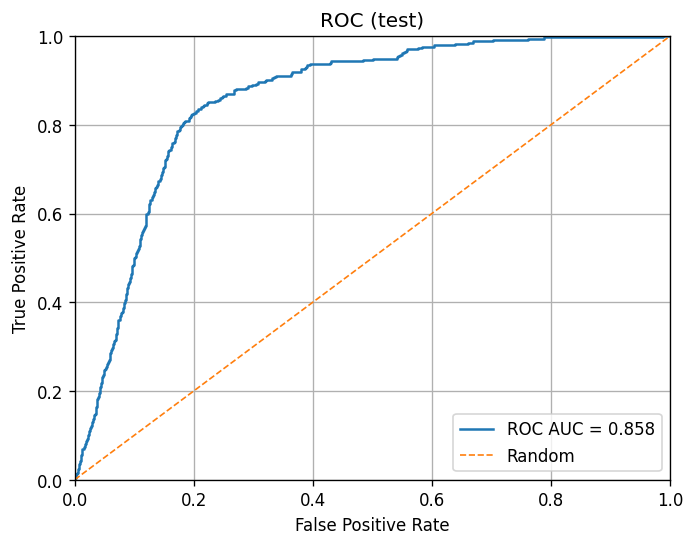

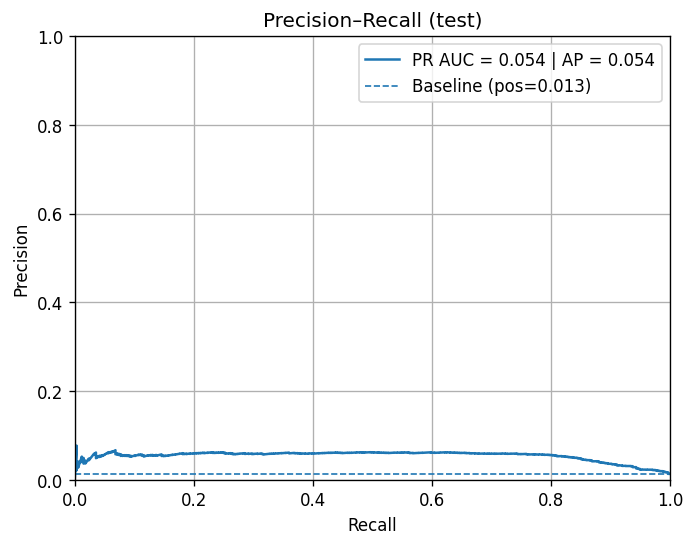

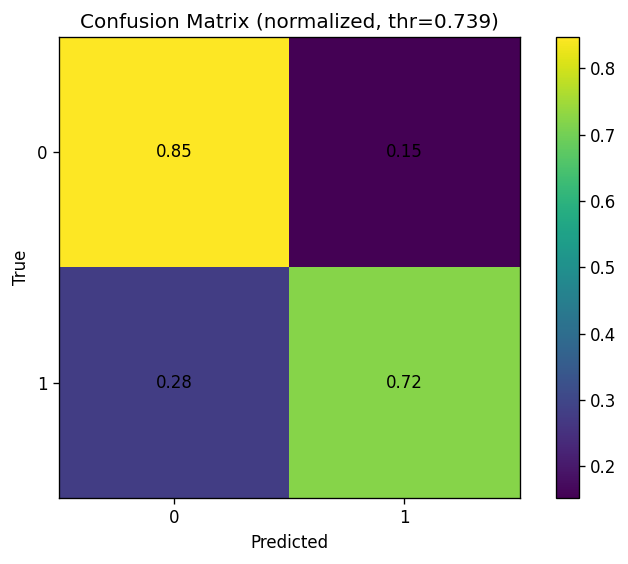

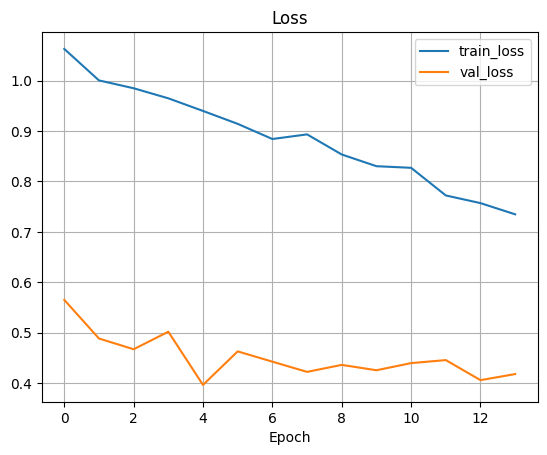

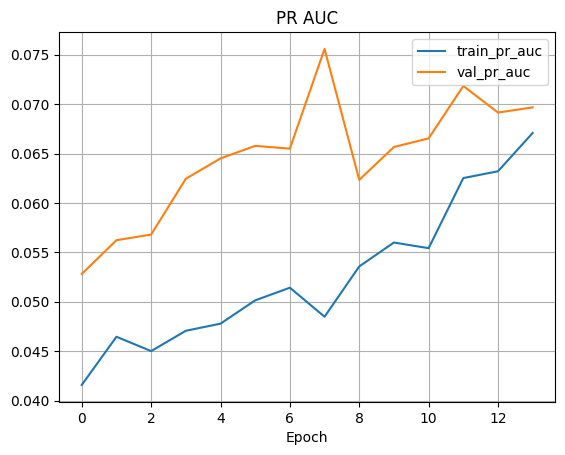

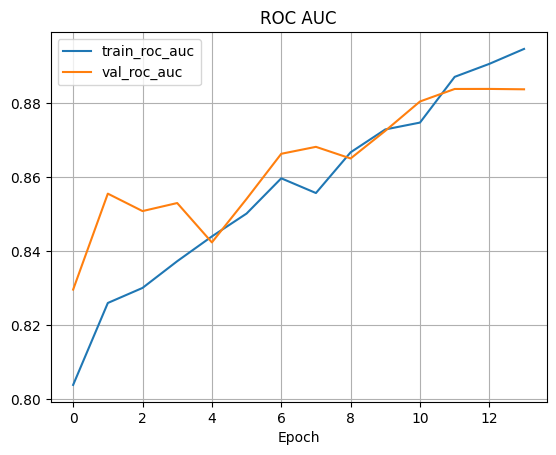

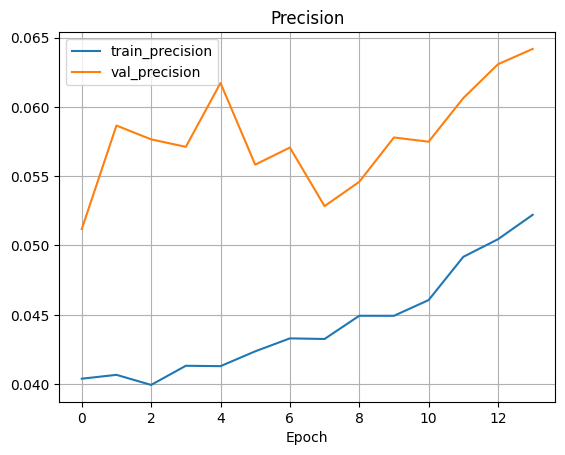

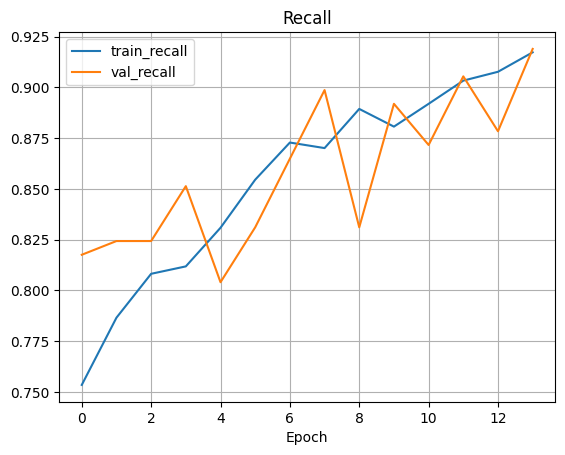

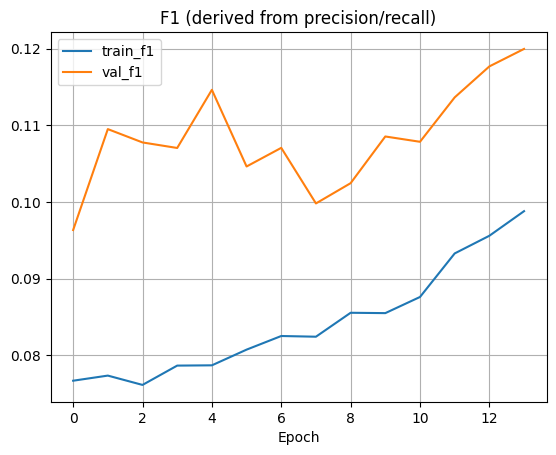

{'metrics': {'roc_auc': 0.857583109511985,
  'pr_auc': 0.05427948223387327,
  'f1': 0.10876404494382023},
 'confusion_matrix': array([[21499,  3872],
        [   94,   242]], dtype=int64),
 'report': '              precision    recall  f1-score   support\n\n           0      0.996     0.847     0.916     25371\n           1      0.059     0.720     0.109       336\n\n    accuracy                          0.846     25707\n   macro avg      0.527     0.784     0.512     25707\nweighted avg      0.983     0.846     0.905     25707\n',
 'expo': {'model_path': 'models\\lstm_dtc.keras.keras',
  'bundle_path': 'models\\scaler_dtc.npy',
  'manifest_path': 'models\\manifest.json'},
 'best_model_path': 'models\\lstm_dtc.keras.keras',
 'threshold': 0.7394900321960449,
 'hpo': {'best_params': {'hidden': 224,
   'dropout': 0.2068841783041968,
   'bidirectional': True,
   'batch_size': 64,
   'epochs': 31,
   'lr': 0.0004142891123020246},
  'chosen_threshold': 0.7394900321960449,
  'study_best_value

In [15]:
train_and_eval(cfg)